# Learning to solve the travelling salesman problem with a Transformer

The **travelling salesman problem** (TSP) asks for the shortest closed tour that visits every city exactly once. It is NP-hard: exact solvers become impractical as the number of cities grows, so in practice it is attacked with heuristics. Here we ask a different question: **can a neural network learn a good heuristic just from examples of optimal tours?**

The data contain 52,000 random instances with 20 cities in the unit square, each with its optimal tour. We will:

1. look at the data and at the classic baselines (random tour, nearest neighbour, 2-opt local search);
2. design a Transformer that reads the cities and outputs a tour one city at a time, **pointing** at the next city;
3. train it on the optimal tours and measure the **optimality gap** on 1,000 unseen instances, alone and combined with sampling and local search.

In [1]:
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(16)
plt.rcParams["figure.dpi"] = 100

## 1. Data and baselines

Each instance is a set of 20 points; each tour is a sequence of 21 city indices that starts and ends at city 0.

In [2]:
data = np.load("data/tsp20.npz")
coords = {s: torch.from_numpy(data[f"{s}_coords"]) for s in ("train", "valid", "test")}
tours = {s: torch.from_numpy(data[f"{s}_tours"]).long() for s in ("train", "valid", "test")}
for s in coords:
    print(f"{s:<6} {tuple(coords[s].shape)} coordinates, {tuple(tours[s].shape)} tours")

def tour_length(xy, tour):
    """Length of closed tours. xy: (B, n, 2), tour: (B, n) city order (the return to the start is implicit)."""
    ordered = xy.gather(1, tour.unsqueeze(-1).expand(-1, -1, 2))
    return (ordered - ordered.roll(-1, dims=1)).norm(dim=-1).sum(1)

optimal = {s: tour_length(coords[s], tours[s][:, :-1]) for s in coords}
print(f"\nmean optimal tour length (test): {optimal['test'].mean():.3f}")

train  (50000, 20, 2) coordinates, (50000, 21) tours
valid  (1000, 20, 2) coordinates, (1000, 21) tours
test   (1000, 20, 2) coordinates, (1000, 21) tours

mean optimal tour length (test): 3.844


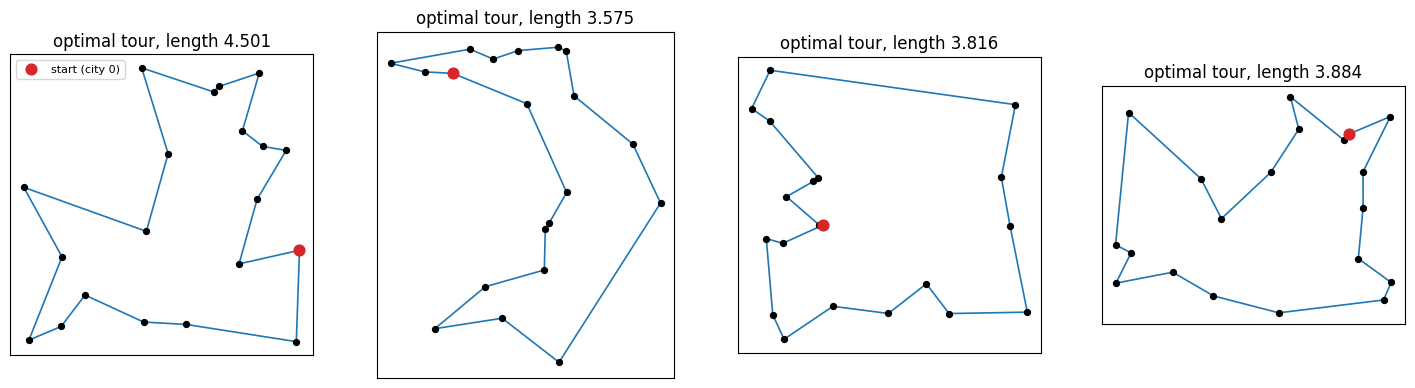

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, i in zip(axes, range(4)):
    xy, t = coords["test"][i], tours["test"][i]
    ax.plot(xy[t, 0], xy[t, 1], "-", color="tab:blue", lw=1.2)
    ax.scatter(xy[:, 0], xy[:, 1], color="black", s=18, zorder=3)
    ax.scatter(*xy[0], color="tab:red", s=60, zorder=4, label="start (city 0)")
    ax.set(title=f"optimal tour, length {optimal['test'][i]:.3f}", aspect="equal", xticks=[], yticks=[])
axes[0].legend(fontsize=8)
plt.show()

Three classic baselines, all evaluated on the test instances:

- **random tour**: a random permutation, the worst reasonable reference;
- **nearest neighbour**: start at city 0 and always go to the closest unvisited city;
- **2-opt**: starting from any tour, repeatedly reverse a segment whenever that shortens the tour, until no improving move is left (a local optimum). It removes crossing edges, the most visible flaw of bad tours.

We report the **optimality gap**: how much longer a tour is than the optimal one, in percent.

In [4]:
def nearest_neighbour(xy):
    n = len(xy)
    dist = torch.cdist(xy, xy)
    tour, visited = [0], torch.zeros(n, dtype=torch.bool)
    visited[0] = True
    for _ in range(n - 1):
        d = dist[tour[-1]].masked_fill(visited, float("inf"))
        nxt = int(d.argmin())
        tour.append(nxt)
        visited[nxt] = True
    return tour

def two_opt(xy, tour):
    dist = torch.cdist(xy, xy).numpy()
    tour = list(tour)
    n = len(tour)
    improved = True
    while improved:
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                a, b, c, d = tour[i - 1], tour[i], tour[j], tour[(j + 1) % n]
                if dist[a, c] + dist[b, d] < dist[a, b] + dist[c, d] - 1e-10:
                    tour[i:j + 1] = reversed(tour[i:j + 1])
                    improved = True
    return tour

def gap(lengths, split="test"):
    return 100 * (lengths / optimal[split] - 1)

xy_test = coords["test"]
gen = torch.Generator().manual_seed(0)
random_tours = torch.stack([torch.cat([torch.zeros(1, dtype=torch.long), torch.randperm(19, generator=gen) + 1]) for _ in range(len(xy_test))])
nn_tours = torch.tensor([nearest_neighbour(xy) for xy in xy_test])
nn_2opt_tours = torch.tensor([two_opt(xy, t) for xy, t in zip(xy_test, nn_tours)])

results = {
    "random tour": gap(tour_length(xy_test, random_tours)),
    "nearest neighbour": gap(tour_length(xy_test, nn_tours)),
    "nearest neighbour + 2-opt": gap(tour_length(xy_test, nn_2opt_tours)),
}
pd.DataFrame({k: {"mean gap %": v.mean().item(), "median gap %": v.median().item(), "optimal found %": 100 * (v < 1e-3).float().mean().item()}
              for k, v in results.items()}).T.round(2)

,mean gap %,median gap %,optimal found %
random tour,172.48,171.52,0.0
nearest neighbour,17.11,16.38,1.2
nearest neighbour + 2-opt,2.52,1.09,35.4


A random tour is almost three times longer than the optimum. Nearest neighbour is a big improvement but still about 17% too long, and 2-opt brings it down to 2.5%, finding the exact optimum on about a third of the instances. These numbers set the bar for the learned model.

## 2. A pointer Transformer

The model has to produce a **permutation of its own input**, so its output vocabulary changes with every instance: "city 7" means a different point in every problem. This rules out a decoder that predicts one of 20 fixed classes or embeds city indices as if they were words. Instead we follow the **pointer** idea:

- **Encoder.** Each city is mapped from its $(x, y)$ coordinates to a 128-dimensional vector, and a Transformer encoder lets every city attend to all others. No positional encoding is used: the input is a *set*, and the order in which cities are listed is meaningless.
- **Decoder.** The partial tour is represented by the encoder vectors of the cities visited so far (plus a positional encoding for their order in the tour). A causal Transformer decoder reads this sequence and attends to all cities.
- **Pointer.** The decoder output at step $t$ is compared with every city vector through a scaled dot product. The resulting scores define a distribution over the **cities**, and cities already visited are masked out, so every output is a valid tour.

Training uses **teacher forcing**: the decoder is fed the first $t$ cities of the optimal tour and asked to predict city $t + 1$, with a cross-entropy loss.

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=32):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2], pe[:, 1::2] = torch.sin(pos * div), torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]


class PointerTransformer(nn.Module):
    def __init__(self, d_model=128, heads=8, enc_layers=3, dec_layers=2, ff=256, dropout=0.0):
        super().__init__()
        self.embed = nn.Linear(2, d_model)
        enc = nn.TransformerEncoderLayer(d_model, heads, ff, dropout, batch_first=True, norm_first=True)
        dec = nn.TransformerDecoderLayer(d_model, heads, ff, dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, enc_layers, enable_nested_tensor=False)
        self.decoder = nn.TransformerDecoder(dec, dec_layers)
        self.position = PositionalEncoding(d_model)
        self.query, self.key = nn.Linear(d_model, d_model), nn.Linear(d_model, d_model)
        self.scale = d_model ** -0.5

    def encode(self, xy):
        return self.encoder(self.embed(xy))                      # (B, n, d)

    def scores(self, memory, prefix):
        """Log-probabilities over cities for every step, given the visited prefix (B, t)."""
        B, t = prefix.shape
        n = memory.size(1)
        steps = memory.gather(1, prefix.unsqueeze(-1).expand(-1, -1, memory.size(-1)))
        causal = torch.triu(torch.ones(t, t, dtype=torch.bool), 1)
        h = self.decoder(self.position(steps), memory, tgt_mask=causal)
        logits = self.scale * self.query(h) @ self.key(memory).transpose(1, 2)    # (B, t, n)
        # mask every city already visited up to and including step s
        visited = F.one_hot(prefix, n).cumsum(1).bool()
        return logits.masked_fill(visited, float("-inf")).log_softmax(-1)

    def forward(self, xy, tour):
        """Teacher forcing: tour (B, 20) with the optimal order; returns the loss."""
        logp = self.scores(self.encode(xy), tour[:, :-1])            # predict cities 2..20
        return F.nll_loss(logp.reshape(-1, logp.size(-1)), tour[:, 1:].reshape(-1))

    @torch.no_grad()
    def decode(self, xy, sample=False):
        memory = self.encode(xy)
        tour = torch.zeros(xy.size(0), 1, dtype=torch.long)          # start at city 0
        for _ in range(xy.size(1) - 1):
            logp = self.scores(memory, tour)[:, -1]
            nxt = torch.multinomial(logp.exp(), 1) if sample else logp.argmax(-1, keepdim=True)
            tour = torch.cat([tour, nxt], 1)
        return tour

model = PointerTransformer()
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 828,416


The decoder recomputes the whole prefix at every step during decoding, which is simple and fast enough for 20 cities.

A subtlety of the data: an optimal tour can be followed in either direction, and both are equally optimal, but the dataset contains only one of them. The first decision after city 0 is therefore partly arbitrary, and the training loss cannot go to zero. We let the model learn from the tours as given and judge it by **tour length**, which does not depend on direction.

## 3. Training

In [6]:
def batches(split, size, shuffle):
    idx = torch.randperm(len(coords[split])) if shuffle else torch.arange(len(coords[split]))
    for start in range(0, len(idx), size):
        b = idx[start:start + size]
        yield coords[split][b], tours[split][b, :-1]

def mean_gap(model, split):
    model.eval()
    lengths = torch.cat([tour_length(xy, model.decode(xy)) for xy, _ in batches(split, 500, False)])
    return gap(lengths, split).mean().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 15
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=epochs * math.ceil(50_000 / 256))
history = []
start = time.time()
for epoch in range(1, epochs + 1):
    model.train()
    total, n = 0.0, 0
    for xy, tour in batches("train", 256, True):
        optimizer.zero_grad()
        loss = model(xy, tour)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total += loss.item() * len(xy)
        n += len(xy)
    model.eval()
    with torch.no_grad():
        val_loss = np.mean([model(xy, tour).item() for xy, tour in batches("valid", 500, False)])
    history.append({"epoch": epoch, "train loss": total / n, "val loss": val_loss, "val gap % (greedy)": mean_gap(model, "valid")})
print(f"training time: {(time.time() - start) / 60:.1f} min")
history = pd.DataFrame(history).set_index("epoch")
history.round(3)

training time: 23.2 min


,train loss,val loss,val gap % (greedy)
epoch,,,
1,1.005,0.465,7.174
2,0.408,0.371,5.530
3,0.356,0.363,6.011
4,0.318,0.341,5.748
5,0.289,0.279,3.075
6,0.259,0.260,3.103
7,0.238,0.222,2.214
8,0.221,0.229,2.301
9,0.206,0.219,1.913


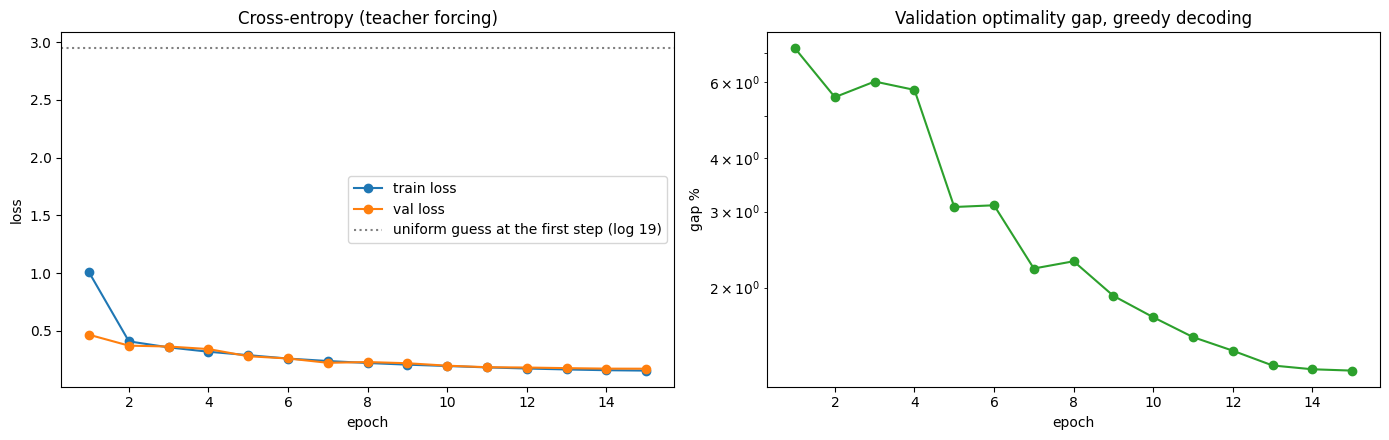

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
history[["train loss", "val loss"]].plot(ax=ax1, marker="o")
ax1.axhline(np.log(19), color="grey", ls=":", label="uniform guess at the first step (log 19)")
ax1.set(title="Cross-entropy (teacher forcing)", ylabel="loss")
ax1.legend()
history["val gap % (greedy)"].plot(ax=ax2, marker="o", color="tab:green")
ax2.set(title="Validation optimality gap, greedy decoding", ylabel="gap %", yscale="log")
fig.tight_layout()
plt.show()

The loss falls steadily without any sign of overfitting: with 50,000 instances, every epoch shows the model new combinations of cities. The validation gap, the quantity we actually care about, falls along with it.

## 4. Evaluation on the test set

Besides **greedy** decoding (always take the most likely city), a probabilistic model offers a cheap improvement: **sample** many tours from the model and keep the shortest. A learned model can also be combined with classic search, for example by refining its tours with 2-opt.

In [8]:
model.eval()
greedy_tours = torch.cat([model.decode(xy) for xy, _ in batches("test", 500, False)])

def best_of_samples(xy_all, k=64, seed=0):
    torch.manual_seed(seed)
    best = []
    for xy in xy_all.split(100):
        rep = xy.repeat_interleave(k, 0)
        cand = model.decode(rep, sample=True)
        lengths = tour_length(rep, cand).view(len(xy), k)
        choice = lengths.argmin(1)
        best.append(cand.view(len(xy), k, -1)[torch.arange(len(xy)), choice])
    return torch.cat(best)

start = time.time()
sampled_tours = best_of_samples(xy_test)
print(f"sampling 64 tours per instance: {time.time() - start:.0f} s")
greedy_2opt = torch.tensor([two_opt(xy, t) for xy, t in zip(xy_test, greedy_tours)])

results["transformer (greedy)"] = gap(tour_length(xy_test, greedy_tours))
results["transformer (best of 64 samples)"] = gap(tour_length(xy_test, sampled_tours))
results["transformer (greedy) + 2-opt"] = gap(tour_length(xy_test, greedy_2opt))
summary = pd.DataFrame({k: {"mean gap %": v.mean().item(), "median gap %": v.median().item(),
                            "optimal found %": 100 * (v < 1e-3).float().mean().item()} for k, v in results.items()}).T
summary.round(2)

sampling 64 tours per instance: 248 s


,mean gap %,median gap %,optimal found %
random tour,172.48,171.52,0.0
nearest neighbour,17.11,16.38,1.2
nearest neighbour + 2-opt,2.52,1.09,35.4
transformer (greedy),1.20,0.28,40.8
transformer (best of 64 samples),0.02,0.00,92.6
transformer (greedy) + 2-opt,0.53,0.00,62.6


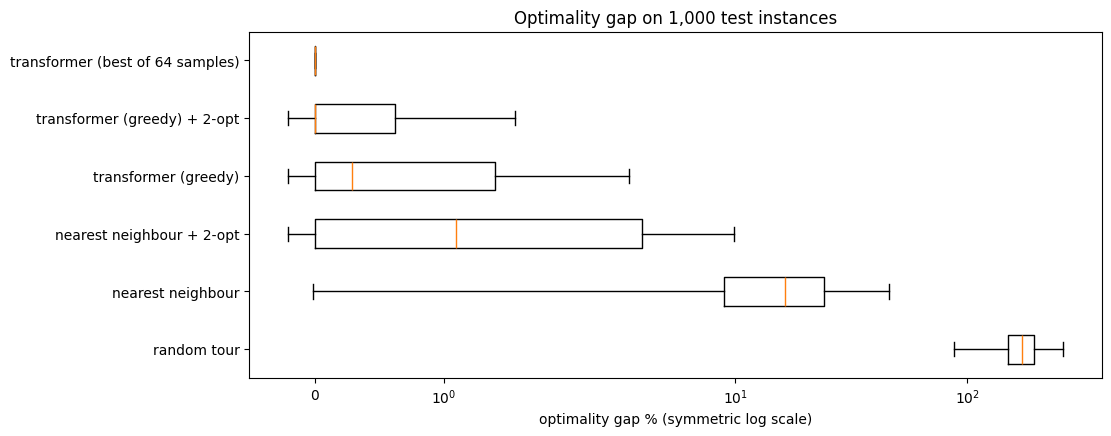

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
order = summary.sort_values("mean gap %", ascending=False).index
ax.boxplot([results[k].numpy() for k in order], vert=False, tick_labels=order, showfliers=False)
ax.set(xscale="symlog", xlabel="optimality gap % (symmetric log scale)", title="Optimality gap on 1,000 test instances")
plt.show()

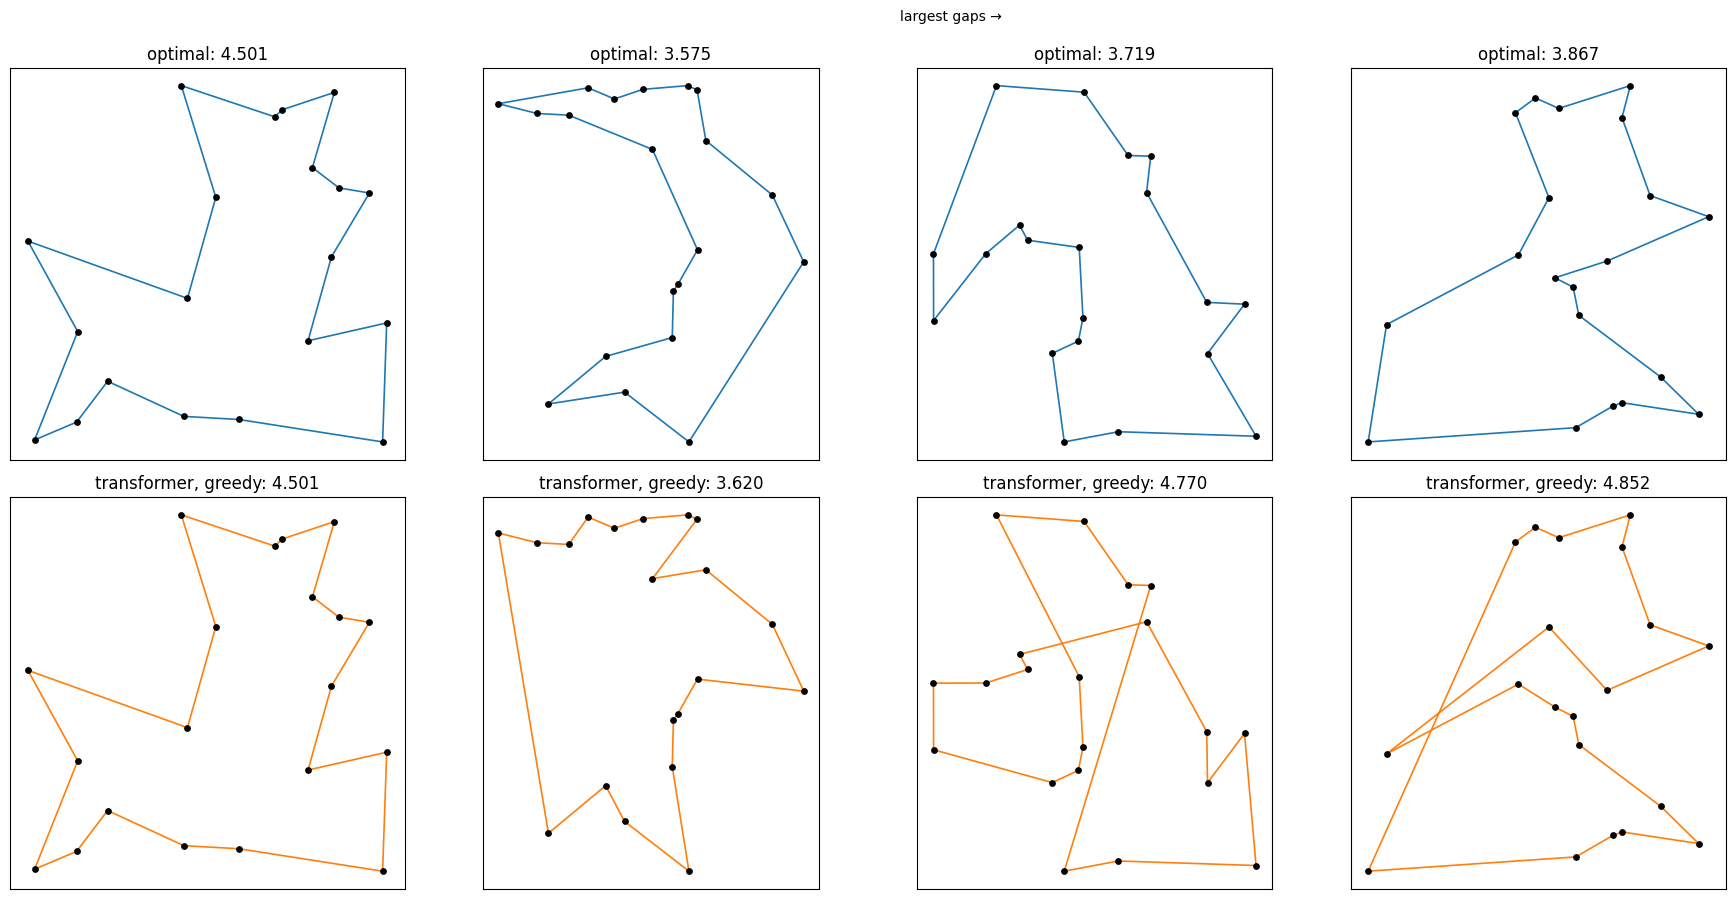

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
worst = results["transformer (greedy)"].argsort(descending=True)
for col, i in enumerate([0, 1, worst[0].item(), worst[1].item()]):
    xy = xy_test[i]
    for row, (name, t) in enumerate([("optimal", tours["test"][i, :-1]), ("transformer, greedy", greedy_tours[i])]):
        ax = axes[row, col]
        closed = torch.cat([t, t[:1]])
        ax.plot(xy[closed, 0], xy[closed, 1], "-", color="tab:blue" if row == 0 else "tab:orange", lw=1.2)
        ax.scatter(xy[:, 0], xy[:, 1], color="black", s=15, zorder=3)
        length = tour_length(xy[None], t[None]).item()
        ax.set(title=f"{name}: {length:.3f}", aspect="equal", xticks=[], yticks=[])
axes[0, 2].annotate("largest gaps \u2192", xy=(-0.05, 1.12), xycoords="axes fraction", fontsize=10)
fig.tight_layout()
plt.show()

The results are striking:

- With plain **greedy decoding**, the Transformer is on average only **1.2%** above the optimum (median 0.3%) and finds the exact optimal tour on 41% of the instances. It beats not only nearest neighbour (17%) but also nearest neighbour refined by 2-opt (2.5%).
- **Sampling** 64 tours and keeping the shortest exploits the fact that the model gives a full probability distribution: where greedy decoding takes a wrong turn, some of the samples take the right one. The mean gap drops to **0.02%**, and the optimal tour is found on **93%** of the instances.
- **2-opt** applied to the greedy tours removes most of their remaining mistakes (gap 0.5%), at a much lower cost than sampling.

The instances where greedy decoding fails (right columns) show a typical pattern: one early wrong choice leaves a few cities behind, and the tour later has to collect them with long edges that cross the rest of the path. Crossing edges are exactly what 2-opt removes, which is why the two methods combine so well.

Some perspective is needed. For 20 cities, exact solvers find the optimum in milliseconds, so this is a learning exercise rather than a practical solver. What it shows is that a network trained only on examples, with no knowledge of the objective, learns most of what makes a tour good. The same architecture is the starting point for research on learned heuristics for larger and messier routing problems, where exact methods do not scale.

## Summary

- Combinatorial outputs such as permutations need a **pointer** mechanism: attention scores over the input elements, with already used elements masked out.
- The encoder treats the cities as a **set** (no positional encoding); the decoder uses positions for the order of the partial tour.
- **Teacher forcing** on optimal tours trains the model efficiently; evaluation must use the real objective (tour length), especially when several outputs are equally correct.
- Trained only on examples, the model outperforms the **nearest neighbour** heuristic even after 2-opt refinement; **sampling** from it finds the optimal tour on more than 90% of the instances.